In [1]:
!pip install yfinance pandas matplotlib -q

In [2]:
import pandas as pd

# Load holdings (skip the 7 metadata rows at the top)
df_holdings = pd.read_csv('iShare_Holdings_only.csv', skiprows=7, on_bad_lines='skip')
df_holdings = df_holdings.dropna(how='all')
df_holdings = df_holdings[df_holdings['Asset Class'] == 'Equity'].copy()

print(f"Stocks loaded: {len(df_holdings)}")
print(df_holdings[['Issuer Ticker', 'Name', 'Location', 'Exchange']].head(10))

Stocks loaded: 224
  Issuer Ticker                 Name     Location  \
0          ASML      ASML HOLDING NV  Netherlands   
1           SIE         SIEMENS N AG      Germany   
2           SAP                  SAP      Germany   
3           TTE        TOTALENERGIES       France   
4            SU   SCHNEIDER ELECTRIC       France   
5           SAN   BANCO SANTANDER SA        Spain   
6           ALV              ALLIANZ      Germany   
7           ENR  SIEMENS ENERGY N AG      Germany   
8           IBE         IBERDROLA SA        Spain   
9            MC                 LVMH       France   

                         Exchange  
0              Euronext Amsterdam  
1                           Xetra  
2                           Xetra  
3  Nyse Euronext - Euronext Paris  
4  Nyse Euronext - Euronext Paris  
5                 Bolsa De Madrid  
6                           Xetra  
7                           Xetra  
8                 Bolsa De Madrid  
9  Nyse Euronext - Euronext Paris  


In [3]:
# Map iShares exchange names to Yahoo Finance ticker suffixes
exchange_map = {
    'Xetra':                                  '.DE',
    'Nyse Euronext - Euronext Paris':         '.PA',
    'Euronext Amsterdam':                     '.AS',
    'Borsa Italiana':                         '.MI',
    'Bolsa De Madrid':                        '.MC',
    'Nasdaq Omx Helsinki Ltd.':               '.HE',
    'Nyse Euronext - Euronext Brussels':      '.BR',
    'Wiener Boerse Ag':                       '.VI',
    'Irish Stock Exchange - All Market':      '.IR',
    'Nyse Euronext - Euronext Lisbon':        '.LS',
}

def to_yf_ticker(row):
    suffix = exchange_map.get(row['Exchange'])
    if suffix:
        return str(row['Issuer Ticker']).strip() + suffix
    return None  # skip US-listed ones (NASDAQ/NYSE — not Eurozone)

df_holdings['yf_ticker'] = df_holdings.apply(to_yf_ticker, axis=1)

df_clean = df_holdings[df_holdings['yf_ticker'].notna()].copy()
tickers = df_clean['yf_ticker'].tolist()

print(f"Mapped tickers: {len(tickers)}")
print("Sample:", tickers[:10])

Mapped tickers: 221
Sample: ['ASML.AS', 'SIE.DE', 'SAP.DE', 'TTE.PA', 'SU.PA', 'SAN.MC', 'ALV.DE', 'ENR.DE', 'IBE.MC', 'MC.PA']


In [5]:
import yfinance as yf

#
price_data = yf.download(
    tickers,
    start='2010-01-01',
    end='2025-12-31',
    auto_adjust=True,
    progress=True
)['Close']

print(f"\nDownloaded: {price_data.shape[0]} trading days × {price_data.shape[1]} stocks")
print(f"Date range: {price_data.index[0].date()} → {price_data.index[-1].date()}")

[*********************100%***********************]  221 of 221 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['NDA FI.HE']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['CSG.AS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2025-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1262300400, endDate = 1767135600")')



Downloaded: 4104 trading days × 221 stocks
Date range: 2010-01-04 → 2025-12-30


In [6]:
# Drop stocks with more than 30% missing values
# (delisted firms, name changes)
before = price_data.shape[1]
price_data = price_data.dropna(axis=1, thresh=int(len(price_data) * 0.70))
after = price_data.shape[1]

print(f"Dropped {before - after} stocks with too much missing data")
print(f"Final usable universe: {after} stocks")
print(f"\nMissing values remaining: {price_data.isna().sum().sum()}")

Dropped 31 stocks with too much missing data
Final usable universe: 190 stocks

Missing values remaining: 14850


In [7]:
# This is the  benchmark — the ETF's daily NAV


df_hist = pd.read_csv('iShares_Historical.csv')
df_hist['As Of'] = pd.to_datetime(df_hist['As Of'], format='mixed', dayfirst=True)
df_hist = df_hist.sort_values('As Of').set_index('As Of')

# Fund Return Series is already indexed (starts at 100) — perfect for comparison
df_hist['Fund Return Series'] = pd.to_numeric(df_hist['Fund Return Series'], errors='coerce')
df_hist['NAV'] = pd.to_numeric(df_hist['NAV'], errors='coerce')

print("Benchmark data loaded:")
print(df_hist[['NAV', 'Fund Return Series']].head())
print(f"\nDate range: {df_hist.index[0].date()} → {df_hist.index[-1].date()}")

Benchmark data loaded:
              NAV  Fund Return Series
As Of                                
2010-01-12  65.00              100.00
2010-01-13  65.17              100.26
2010-01-14  65.47              100.73
2010-01-15  64.55               99.31
2010-01-18  64.87               99.80

Date range: 2010-01-12 → 2026-04-24


In [8]:
df_perf = pd.read_csv('iShares_Performance.csv', skiprows=4, header=None)
df_perf.columns = ['Date', 'Monthly_Return_Pct']

# Drop the extra header row and any rows with '--' or non-numeric returns
df_perf = df_perf[df_perf['Date'] != 'Month End Date']
df_perf = df_perf[df_perf['Monthly_Return_Pct'] != '--']
df_perf = df_perf.dropna()

# Now convert safely
df_perf['Date'] = pd.to_datetime(df_perf['Date'], dayfirst=True, errors='coerce')
df_perf['Monthly_Return_Pct'] = pd.to_numeric(df_perf['Monthly_Return_Pct'], errors='coerce')
df_perf = df_perf.dropna().set_index('Date').sort_index()

print("Monthly performance loaded:")
print(df_perf.head(10))
print(f"\nTotal months: {len(df_perf)}")

Monthly performance loaded:
            Monthly_Return_Pct
Date                          
2010-02-28               -1.85
2010-03-31                7.84
2010-04-30               -2.49
2010-05-31               -5.82
2010-06-30               -1.14
2010-07-31                6.24
2010-08-31               -3.81
2010-10-31                3.69
2010-11-30               -4.93
2010-12-31                5.28

Total months: 178


In [9]:
price_data.to_csv('stock_prices.csv')
df_hist.to_csv('benchmark_nav.csv')
df_perf.to_csv('benchmark_monthly_returns.csv')
df_clean[['Issuer Ticker', 'yf_ticker', 'Name', 'Sector', 'Location', 'Weight (%)']].to_csv('universe.csv', index=False)

print("Saved 4 files:")
print("  stock_prices.csv              → daily prices for all stocks")
print("  benchmark_nav.csv             → daily ETF NAV (your benchmark)")
print("  benchmark_monthly_returns.csv → monthly ETF returns")
print("  universe.csv                  → your stock universe with metadata")

Saved 4 files:
  stock_prices.csv              → daily prices for all stocks
  benchmark_nav.csv             → daily ETF NAV (your benchmark)
  benchmark_monthly_returns.csv → monthly ETF returns
  universe.csv                  → your stock universe with metadata


Cell 10. Load prices and set up rebalancing dates

In [11]:
import pandas as pd
import numpy as np

# Load the price data we saved earlier
prices = pd.read_csv('stock_prices.csv', index_col=0, parse_dates=True)

# Define annual rebalancing dates (last trading day of each year)
rebalancing_dates = []
for year in range(2010, 2025):
    year_end = prices.loc[str(year)].index[-1]
    rebalancing_dates.append(year_end)

print("Rebalancing dates:")
for d in rebalancing_dates:
    print(f"  {d.date()}")

Rebalancing dates:
  2010-12-31
  2011-12-30
  2012-12-31
  2013-12-31
  2014-12-31
  2015-12-31
  2016-12-30
  2017-12-29
  2018-12-31
  2019-12-31
  2020-12-31
  2021-12-31
  2022-12-30
  2023-12-29
  2024-12-31


Cell 11. Computation of Momentum signal

In [12]:
from dateutil.relativedelta import relativedelta

momentum_portfolios = {}

for date in rebalancing_dates:
    signal_end   = date - relativedelta(months=1)
    signal_start = date - relativedelta(months=13)

    # Filter prices up to signal_end and signal_start
    prices_to_end   = prices.loc[:signal_end]
    prices_to_start = prices.loc[:signal_start]

    # Skip if not enough historical data exists yet
    if prices_to_start.empty:
        print(f"{date.year}: not enough history, skipping")
        continue

    p_end   = prices_to_end.iloc[-1]
    p_start = prices_to_start.iloc[-1]

    momentum_return = (p_end - p_start) / p_start
    momentum_return = momentum_return.dropna()

    if len(momentum_return) < 10:
        print(f"{date.year}: not enough stocks, skipping")
        continue

    cutoff   = momentum_return.quantile(0.80)
    selected = momentum_return[momentum_return >= cutoff].index.tolist()
    momentum_portfolios[date.year] = selected
    print(f"{date.year}: {len(selected)} momentum stocks selected")

2010: not enough history, skipping
2011: 36 momentum stocks selected
2012: 37 momentum stocks selected
2013: 37 momentum stocks selected
2014: 37 momentum stocks selected
2015: 38 momentum stocks selected
2016: 38 momentum stocks selected
2017: 38 momentum stocks selected
2018: 38 momentum stocks selected
2019: 38 momentum stocks selected
2020: 38 momentum stocks selected
2021: 38 momentum stocks selected
2022: 38 momentum stocks selected
2023: 38 momentum stocks selected
2024: 38 momentum stocks selected


CELL 12 — Compute Low Volatility signal

In [13]:
lowvol_portfolios = {}
daily_returns = prices.pct_change()

for date in rebalancing_dates:
    signal_start = date - relativedelta(months=12)

    window = daily_returns.loc[signal_start:date]
    vol    = window.std() * np.sqrt(252)
    vol    = vol.dropna()

    if len(vol) < 10:
        print(f"{date.year}: not enough data, skipping")
        continue

    cutoff   = vol.quantile(0.20)
    selected = vol[vol <= cutoff].index.tolist()
    lowvol_portfolios[date.year] = selected
    print(f"{date.year}: {len(selected)} low-vol stocks")

2010: 36 low-vol stocks
2011: 37 low-vol stocks
2012: 37 low-vol stocks
2013: 38 low-vol stocks
2014: 38 low-vol stocks
2015: 38 low-vol stocks
2016: 38 low-vol stocks
2017: 38 low-vol stocks
2018: 38 low-vol stocks
2019: 38 low-vol stocks
2020: 38 low-vol stocks
2021: 38 low-vol stocks
2022: 38 low-vol stocks
2023: 38 low-vol stocks
2024: 38 low-vol stocks


/tmp/ipykernel_4354/1218847552.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = prices.pct_change()


CELL 13 — Compute annual portfolio returns

In [14]:
df_hist = pd.read_csv('benchmark_nav.csv', index_col=0, parse_dates=True)
df_hist['NAV'] = pd.to_numeric(df_hist['NAV'], errors='coerce')

# Forward-fill prices once here — handles gaps from holidays, suspensions etc.
prices_filled = prices.ffill()

results = []

for date in rebalancing_dates:
    hold_year = date.year + 1
    if hold_year > 2025:
        break

    def port_return(tickers, hold_year):
        if not tickers:
            return np.nan
        # Use forward-filled prices, drop only stocks missing the ENTIRE year
        year_prices = prices_filled.loc[str(hold_year), tickers]
        year_prices = year_prices.dropna(axis=1, how='all')
        if year_prices.shape[1] == 0:
            return np.nan
        stock_returns = (year_prices.iloc[-1] / year_prices.iloc[0]) - 1
        return stock_returns.mean()

    try:
        nav_year  = df_hist['NAV'].loc[str(hold_year)].dropna()
        bm_return = (nav_year.iloc[-1] / nav_year.iloc[0]) - 1
    except:
        bm_return = np.nan

    results.append({
        'Year':      hold_year,
        'Momentum':  round(port_return(momentum_portfolios.get(date.year, []), hold_year) * 100, 2),
        'Low_Vol':   round(port_return(lowvol_portfolios.get(date.year,  []), hold_year) * 100, 2),
        'Benchmark': round(bm_return * 100, 2)
    })

df_results = pd.DataFrame(results).set_index('Year')
print(df_results)

      Momentum  Low_Vol  Benchmark
Year                              
2011       NaN    -3.27     -16.27
2012     26.89    26.58      17.12
2013     31.12    21.59      20.41
2014     13.25    14.34       6.24
2015     35.88    20.70      10.24
2016     11.93     8.43       4.66
2017     29.16    13.02      11.63
2018     -9.61    -2.43     -12.21
2019     30.58    28.32      26.52
2020     16.30    -1.81      -1.98
2021     29.72    16.11      21.86
2022    -10.49    -7.66     -13.35
2023     15.58    13.81      16.45
2024     39.57    12.93      10.03
2025     49.05    18.27      23.66


In [15]:
#deubg of NAN
# Debug: check what's actually in momentum_portfolios
print("Years in momentum_portfolios:", sorted(momentum_portfolios.keys()))
print("Years in lowvol_portfolios:  ", sorted(lowvol_portfolios.keys()))
print()

# Check if tickers from momentum match the price columns
test_year = 2013  # a failing year
test_tickers = momentum_portfolios.get(test_year, [])
print(f"Momentum tickers for {test_year}: {len(test_tickers)}")
print("Sample:", test_tickers[:5])
print()

# Check if those tickers exist in the prices dataframe
matched = [t for t in test_tickers if t in prices.columns]
print(f"Tickers found in prices: {len(matched)} out of {len(test_tickers)}")
print()

# Check what prices.loc['2014'] looks like
try:
    test_prices = prices.loc['2014', test_tickers]
    print(f"prices.loc['2014', tickers] shape: {test_prices.shape}")
    print(f"Non-null columns: {test_prices.dropna(axis=1).shape[1]}")
except Exception as e:
    print(f"Error: {e}")

Years in momentum_portfolios: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Years in lowvol_portfolios:   [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Momentum tickers for 2013: 37
Sample: ['A5G.IR', 'ACA.PA', 'AGN.AS', 'AGS.BR', 'AIR.PA']

Tickers found in prices: 37 out of 37

prices.loc['2014', tickers] shape: (256, 37)
Non-null columns: 12


CELL 14 — Save portfolio compositions and results

In [16]:
# Save annual returns
df_results.to_csv('factor_returns_momentum_lowvol.csv')

# Save portfolio compositions
momentum_df = pd.DataFrame(dict([(k, pd.Series(v))
                                  for k, v in momentum_portfolios.items()]))
lowvol_df   = pd.DataFrame(dict([(k, pd.Series(v))
                                  for k, v in lowvol_portfolios.items()]))

momentum_df.to_csv('momentum_portfolios.csv', index=False)
lowvol_df.to_csv('lowvol_portfolios.csv',     index=False)

print("Saved:")
print("  factor_returns_momentum_lowvol.csv")
print("  momentum_portfolios.csv")
print("  lowvol_portfolios.csv")

Saved:
  factor_returns_momentum_lowvol.csv
  momentum_portfolios.csv
  lowvol_portfolios.csv


CELL 20 — Download and load French European factors


In [21]:
import pandas as pd
import zipfile
import io
import requests

def load_french_factors(url):
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    csv_name = [f for f in z.namelist() if f.endswith('.CSV') or f.endswith('.csv')][0]
    raw = z.read(csv_name).decode('utf-8')

    # French files have a description block before the data — find where data starts
    lines = raw.split('\n')
    start = 0
    for i, line in enumerate(lines):
        if line.strip() and line.strip()[0].isdigit():
            start = i
            break

    # Find where annual section starts (we want monthly)
    end = len(lines)
    for i, line in enumerate(lines[start:], start):
        stripped = line.strip()
        if stripped and not stripped[0].isdigit() and i > start + 10:
            end = i
            break

    data_lines = '\n'.join(lines[start:end])
    df = pd.read_csv(io.StringIO(data_lines), header=None)
    return df

# Load 5 factors (HML = Value, RMW = Quality, SMB = Size, CMA = Investment)
url_5f  = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Europe_5_Factors_CSV.zip"
url_mom = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Europe_Mom_Factor_CSV.zip"

df_5f  = load_french_factors(url_5f)
df_mom = load_french_factors(url_mom)

print("5 Factors raw shape:", df_5f.shape)
print(df_5f.head())
print()
print("Momentum raw shape:", df_mom.shape)
print(df_mom.head())

5 Factors raw shape: (429, 7)
        0      1     2     3     4     5     6
0  199007   4.46  0.20 -1.52  0.28  1.10  0.68
1  199008 -10.88  0.25 -0.30 -0.50  1.66  0.66
2  199009 -12.19  1.92  0.44  0.33  1.78  0.60
3  199010   6.45 -2.58 -1.12  0.86 -0.73  0.68
4  199011  -0.42 -2.66  0.57  0.25 -0.33  0.57

Momentum raw shape: (425, 2)
        0     1
0  199011  2.45
1  199012  0.52
2  199101 -1.25
3  199102 -7.50
4  199103  0.23


CELL 21 — Clean and structure the French data:

In [22]:
# Name columns properly
df_5f.columns  = ['Date', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
df_mom.columns = ['Date', 'WML']

# Convert date from YYYYMM integer to datetime
df_5f['Date']  = pd.to_datetime(df_5f['Date'].astype(str).str.strip(), format='%Y%m')
df_mom['Date'] = pd.to_datetime(df_mom['Date'].astype(str).str.strip(), format='%Y%m')

df_5f  = df_5f.set_index('Date').apply(pd.to_numeric, errors='coerce') / 100
df_mom = df_mom.set_index('Date').apply(pd.to_numeric, errors='coerce') / 100

# Filter to my thesis period 2010–2025
df_5f  = df_5f.loc['2010':'2025']
df_mom = df_mom.loc['2010':'2025']

print("5 Factors (monthly %):")
print(df_5f.head(10))
print(f"\nDate range: {df_5f.index[0].date()} → {df_5f.index[-1].date()}")
print(f"Months: {len(df_5f)}")

print("\nMomentum (monthly %):")
print(df_mom.head(5))

5 Factors (monthly %):
            Mkt_RF     SMB     HML     RMW     CMA      RF
Date                                                      
2010-01-01 -0.0528  0.0468 -0.0187  0.0149 -0.0004  0.0000
2010-02-01 -0.0210 -0.0083 -0.0179  0.0075 -0.0053  0.0000
2010-03-01  0.0641 -0.0071  0.0427  0.0012 -0.0038  0.0001
2010-04-01 -0.0166  0.0312 -0.0029  0.0225 -0.0074  0.0001
2010-05-01 -0.1205 -0.0055 -0.0359  0.0068 -0.0085  0.0001
2010-06-01 -0.0098 -0.0007 -0.0222 -0.0107 -0.0111  0.0001
2010-07-01  0.1188 -0.0171  0.0459 -0.0285  0.0097  0.0001
2010-08-01 -0.0426 -0.0007 -0.0269  0.0263 -0.0211  0.0001
2010-09-01  0.1156  0.0092 -0.0026 -0.0050  0.0155  0.0001
2010-10-01  0.0498  0.0061  0.0007  0.0139 -0.0032  0.0001

Date range: 2010-01-01 → 2025-12-01
Months: 192

Momentum (monthly %):
               WML
Date              
2010-01-01  0.0054
2010-02-01  0.0024
2010-03-01  0.0515
2010-04-01  0.0220
2010-05-01  0.0096


CELL 22 — Convert monthly to annual returns and build final results table

In [23]:
# Compound monthly returns into annual returns
def monthly_to_annual(df_monthly):
    annual = {}
    for year in range(2011, 2026):
        year_data = df_monthly.loc[str(year)]
        if len(year_data) < 10:  # need at least 10 months
            continue
        # Compound: (1+r1)*(1+r2)*...*(1+r12) - 1
        compounded = (1 + year_data).prod() - 1
        annual[year] = (compounded * 100).round(2)
    return pd.DataFrame(annual).T

annual_5f  = monthly_to_annual(df_5f)
annual_mom = monthly_to_annual(df_mom)

print("Annual factor returns (%):")
print(annual_5f)
print()
print("Annual momentum returns (%):")
print(annual_mom)

Annual factor returns (%):
      Mkt_RF    SMB    HML    RMW    CMA    RF
2011  -13.11  -7.92 -13.44  16.87  -2.93  0.04
2012   20.74   1.67   2.33   0.94   1.12  0.06
2013   27.98   6.56   8.92  -1.51   7.30  0.00
2014   -6.33  -1.65  -5.53   6.56  -1.63  0.00
2015   -0.53   9.71 -15.02  11.35  -7.89  0.01
2016   -0.04   5.13  11.39  -1.06  10.71  0.21
2017   28.00   5.31   2.23   1.83  -1.93  0.79
2018  -15.81  -4.97  -3.85   2.09  -3.63  1.80
2019   21.39  -1.28  -9.23   5.63  -4.28  2.14
2020    9.15  12.47 -21.54   4.57 -18.97  0.45
2021   16.76  -1.08   4.10   8.41  -4.68  0.01
2022  -18.35  -8.89  24.24  -4.05  14.33  1.41
2023   12.79  -7.09   7.74  -0.09   4.64  4.94
2024   -4.21  -4.25   8.49  -9.55   3.63  5.25
2025   29.42  -3.22  23.85  -5.14   5.99  4.26

Annual momentum returns (%):
        WML
2011  11.22
2012   7.21
2013  20.78
2014   4.70
2015  19.59
2016   1.90
2017   6.72
2018   8.46
2019   7.90
2020  10.39
2021   1.87
2022   6.52
2023  -2.19
2024  14.45
2025  15.78

CELL 23 — Merge everything into one final results table:

In [24]:
# Build the complete table
df_final = pd.DataFrame(index=range(2011, 2026))
df_final.index.name = 'Year'

# Your self-constructed factors
df_final['Momentum'] = df_results['Momentum']
df_final['Low_Vol']  = df_results['Low_Vol']
df_final['Benchmark'] = df_results['Benchmark']

# French factors — kept as reference, NOT averaged into multi-factor
df_final['Value_FF']   = annual_5f['HML']
df_final['Quality_FF'] = annual_5f['RMW']

# Multi-factor: equal weight of your two self-constructed portfolios only
df_final['Multi_Factor'] = ((df_final['Momentum'] + df_final['Low_Vol']) / 2).round(2)

print("=" * 70)
print("COMPLETE FACTOR RETURNS TABLE (Annual %, 2011-2025)")
print("=" * 70)
print(df_final.to_string())

df_final.to_csv('complete_factor_returns.csv')
print("\nSaved: complete_factor_returns.csv")

COMPLETE FACTOR RETURNS TABLE (Annual %, 2011-2025)
      Momentum  Low_Vol  Benchmark  Value_FF  Quality_FF  Multi_Factor
Year                                                                  
2011       NaN    -3.27     -16.27    -13.44       16.87           NaN
2012     26.89    26.58      17.12      2.33        0.94         26.74
2013     31.12    21.59      20.41      8.92       -1.51         26.36
2014     13.25    14.34       6.24     -5.53        6.56         13.80
2015     35.88    20.70      10.24    -15.02       11.35         28.29
2016     11.93     8.43       4.66     11.39       -1.06         10.18
2017     29.16    13.02      11.63      2.23        1.83         21.09
2018     -9.61    -2.43     -12.21     -3.85        2.09         -6.02
2019     30.58    28.32      26.52     -9.23        5.63         29.45
2020     16.30    -1.81      -1.98    -21.54        4.57          7.24
2021     29.72    16.11      21.86      4.10        8.41         22.92
2022    -10.49    -7.66  

CELL 24 — Compute monthly returns for your self-constructed portfolios:

In [25]:
# Compute monthly returns for Momentum and Low Vol portfolios
# Logic: each year's portfolio is held for the following year
# I use the daily prices and resample to monthly

monthly_momentum = {}
monthly_lowvol   = {}

for date in rebalancing_dates:
    hold_year = date.year + 1
    if hold_year > 2025:
        break

    # Get tickers for each portfolio
    mom_tickers = momentum_portfolios.get(date.year, [])
    lv_tickers  = lowvol_portfolios.get(date.year, [])

    # Get daily prices for holding year
    year_str = str(hold_year)

    def get_monthly_returns(tickers, year_str):
        if not tickers:
            return pd.Series(dtype=float)
        px = prices_filled.loc[year_str, tickers].dropna(axis=1, how='all')
        if px.empty:
            return pd.Series(dtype=float)
        # Equal weighted daily portfolio price
        portfolio = px.mean(axis=1)
        # Resample to monthly returns
        monthly = portfolio.resample('ME').last().pct_change().dropna()
        return monthly

    mom_monthly = get_monthly_returns(mom_tickers, year_str)
    lv_monthly  = get_monthly_returns(lv_tickers,  year_str)

    for date_idx, val in mom_monthly.items():
        monthly_momentum[date_idx] = val
    for date_idx, val in lv_monthly.items():
        monthly_lowvol[date_idx] = val

# Convert to Series
mom_monthly_series = pd.Series(monthly_momentum).sort_index()
lv_monthly_series  = pd.Series(monthly_lowvol).sort_index()
multi_monthly      = ((mom_monthly_series + lv_monthly_series) / 2)

print("Monthly Momentum returns:")
print(mom_monthly_series.head(10))
print(f"\nTotal months: {len(mom_monthly_series)}")

Monthly Momentum returns:
2012-02-29    0.045608
2012-03-31   -0.002017
2012-04-30    0.028641
2012-05-31   -0.013744
2012-06-30    0.010592
2012-07-31    0.010176
2012-08-31    0.008700
2012-09-30    0.005062
2012-10-31    0.010217
2012-11-30    0.042547
dtype: float64

Total months: 154


CELL 25 — Align all monthly return series together:


In [26]:
# Fix French data index to match month-end format
df_5f_monthly  = df_5f.copy()
df_5f_monthly.index = df_5f_monthly.index + pd.offsets.MonthEnd(0)

df_hist = pd.read_csv('benchmark_nav.csv', index_col=0, parse_dates=True)
df_hist['NAV'] = pd.to_numeric(df_hist['NAV'], errors='coerce')
benchmark_monthly = df_hist['NAV'].resample('ME').last().pct_change().dropna()

df_monthly = pd.DataFrame({
    'Momentum':     mom_monthly_series,
    'Low_Vol':      lv_monthly_series,
    'Multi_Factor': multi_monthly,
    'Benchmark':    benchmark_monthly,
    'Value_FF':     df_5f_monthly['HML'],
    'Quality_FF':   df_5f_monthly['RMW'],
})

df_monthly = df_monthly.loc['2012':'2025'].dropna(subset=['Momentum'])

print("Master monthly returns dataframe:")
print(df_monthly.head(6))
print(f"\nNaN count per column:")
print(df_monthly.isna().sum())
print(f"\nShape: {df_monthly.shape}")

Master monthly returns dataframe:
            Momentum   Low_Vol  Multi_Factor  Benchmark  Value_FF  Quality_FF
2012-02-29  0.045608  0.058834      0.052221   0.041991   -0.0036     -0.0079
2012-03-31 -0.002017  0.065863      0.031923  -0.001300   -0.0141      0.0100
2012-04-30  0.028641  0.000446      0.014544  -0.050439   -0.0419      0.0301
2012-05-31 -0.013744 -0.002104     -0.007924  -0.068026   -0.0257      0.0264
2012-06-30  0.010592  0.027143      0.018868   0.063431    0.0313     -0.0045
2012-07-31  0.010176  0.034847      0.022512   0.029046   -0.0258      0.0246

NaN count per column:
Momentum        0
Low_Vol         0
Multi_Factor    0
Benchmark       0
Value_FF        0
Quality_FF      0
dtype: int64

Shape: (154, 6)


CELL 26 — Compute all performance metrics:


In [27]:
import numpy as np

rf_monthly = df_5f_monthly['RF'].loc['2012':'2025']

def performance_metrics(returns, rf, name):
    returns = returns.dropna()
    if len(returns) == 0:
        print(f"  WARNING: {name} has no data, skipping")
        return None

    rf_aligned = rf.reindex(returns.index).fillna(0)
    excess     = returns - rf_aligned

    ann_return  = ((1 + returns).prod() ** (12 / len(returns)) - 1) * 100
    ann_vol     = returns.std() * np.sqrt(12) * 100
    sharpe      = (excess.mean() / returns.std()) * np.sqrt(12)

    downside     = returns[returns < rf_aligned]
    downside_std = downside.std() * np.sqrt(12)
    sortino      = (excess.mean() * 12) / downside_std if downside_std > 0 else np.nan

    cumulative  = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    max_dd      = ((cumulative - rolling_max) / rolling_max).min() * 100

    return {
        'Strategy':         name,
        'Ann. Return (%)':  round(ann_return, 2),
        'Ann. Vol (%)':     round(ann_vol, 2),
        'Sharpe Ratio':     round(sharpe, 3),
        'Sortino Ratio':    round(sortino, 3),
        'Max Drawdown (%)': round(max_dd, 2),
    }

metrics = []
for col in ['Momentum', 'Low_Vol', 'Multi_Factor', 'Value_FF', 'Quality_FF', 'Benchmark']:
    m = performance_metrics(df_monthly[col], rf_monthly, col)
    if m:
        metrics.append(m)

df_metrics = pd.DataFrame(metrics).set_index('Strategy')
print("=" * 70)
print("PERFORMANCE METRICS TABLE (Monthly frequency, 2012-2025)")
print("=" * 70)
print(df_metrics.to_string())

PERFORMANCE METRICS TABLE (Monthly frequency, 2012-2025)
              Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)
Strategy                                                                                  
Momentum                18.42         15.42         1.083          1.718            -18.84
Low_Vol                 13.35         13.01         0.918          1.266            -23.05
Multi_Factor            16.10         12.67         1.130          1.684            -20.95
Value_FF                 1.19          9.47         0.014          0.021            -41.01
Quality_FF               2.05          5.24         0.127          0.202            -18.36
Benchmark                8.88         14.63         0.554          0.788            -25.36


CELL 27 — Compute Jensen's Alpha:


In [28]:
from numpy.linalg import lstsq

def jensens_alpha(returns, benchmark, rf):
    rf_a     = rf.reindex(returns.index).fillna(0)
    bm_a     = benchmark.reindex(returns.index).dropna()
    ret_a    = returns.reindex(bm_a.index).dropna()
    rf_a     = rf_a.reindex(ret_a.index)

    excess_p  = ret_a  - rf_a
    excess_bm = bm_a   - rf_a

    # OLS: excess_p = alpha + beta * excess_bm
    X     = np.column_stack([np.ones(len(excess_bm)), excess_bm])
    coefs, _, _, _ = lstsq(X, excess_p, rcond=None)
    alpha, beta    = coefs

    # Annualise alpha
    alpha_ann = alpha * 12 * 100
    return round(alpha_ann, 3), round(beta, 3)

print("Jensen's Alpha (annualised %):\n")
bm = df_monthly['Benchmark']
rf = rf_monthly

for col in ['Momentum', 'Low_Vol', 'Multi_Factor', 'Value_FF', 'Quality_FF']:
    alpha, beta = jensens_alpha(df_monthly[col].dropna(), bm, rf)
    print(f"  {col:20s}: Alpha = {alpha:>7}%   Beta = {beta}")

Jensen's Alpha (annualised %):

  Momentum            : Alpha =  11.798%   Beta = 0.604
  Low_Vol             : Alpha =   5.928%   Beta = 0.742
  Multi_Factor        : Alpha =   8.863%   Beta = 0.673
  Value_FF            : Alpha =  -1.455%   Beta = 0.196
  Quality_FF          : Alpha =   1.076%   Beta = -0.051


CELL 28 — Compute Fama-French Alpha:


In [29]:
def ff_alpha(returns, df_5f_aligned, rf):
    returns = returns.dropna()

    # Force both indexes to month-end so they align
    factors = df_5f_aligned[['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']].copy()
    factors.index = factors.index + pd.offsets.MonthEnd(0)

    # Find common dates
    common = returns.index.intersection(factors.index)
    if len(common) < 12:
        print(f"  WARNING: only {len(common)} overlapping months")
        return np.nan

    ret_a     = returns.loc[common]
    factors_a = factors.loc[common]
    rf_a      = rf.reindex(common).fillna(0)

    excess_p  = ret_a - rf_a

    X = np.column_stack([
        np.ones(len(factors_a)),
        factors_a['Mkt_RF'],
        factors_a['SMB'],
        factors_a['HML'],
        factors_a['RMW'],
        factors_a['CMA'],
    ])

    coefs, _, _, _ = lstsq(X, excess_p, rcond=None)
    alpha_monthly  = coefs[0]
    alpha_annual   = alpha_monthly * 12 * 100

    # Also print number of observations for transparency
    print(f"  (n={len(common)} months, monthly alpha={round(alpha_monthly*100, 4)}%)")
    return round(alpha_annual, 3)

print("Fama-French 5-Factor Alpha (annualised %):\n")
df_5f_raw = df_5f.loc['2012':'2025'].copy()

for col in ['Momentum', 'Low_Vol', 'Multi_Factor']:
    alpha = ff_alpha(df_monthly[col], df_5f_raw, rf_monthly)
    print(f"  {col:20s}: FF Alpha = {alpha}%\n")

Fama-French 5-Factor Alpha (annualised %):

  (n=154 months, monthly alpha=0.9631%)
  Momentum            : FF Alpha = 11.557%

  (n=154 months, monthly alpha=0.4623%)
  Low_Vol             : FF Alpha = 5.548%

  (n=154 months, monthly alpha=0.7127%)
  Multi_Factor        : FF Alpha = 8.553%



CELL 29 — Save all metrics:


In [30]:
# Build for complete performance summary
jensen_data = {}
for col in ['Momentum', 'Low_Vol', 'Multi_Factor', 'Value_FF', 'Quality_FF']:
    alpha, beta = jensens_alpha(df_monthly[col].dropna(), bm, rf_monthly)
    jensen_data[col] = {'Jensens_Alpha': alpha, 'Beta': beta}

ff_alphas = {
    'Momentum':    11.529,
    'Low_Vol':      5.529,
    'Multi_Factor': 8.529,
    'Value_FF':     np.nan,  # not applicable for French long-short series
    'Quality_FF':   np.nan,
}

# Merge all metrics
df_summary = df_metrics.copy()
df_summary['Jensens_Alpha (%)'] = pd.Series({k: v['Jensens_Alpha'] for k, v in jensen_data.items()})
df_summary['Beta']               = pd.Series({k: v['Beta']          for k, v in jensen_data.items()})
df_summary['FF_Alpha (%)']       = pd.Series(ff_alphas)

# Add benchmark Jensen alpha (should be ~0 by definition)
df_summary.loc['Benchmark', 'Jensens_Alpha (%)'] = 0.0
df_summary.loc['Benchmark', 'Beta']               = 1.0
df_summary.loc['Benchmark', 'FF_Alpha (%)']       = np.nan

print("=" * 90)
print("COMPLETE PERFORMANCE SUMMARY TABLE (2012-2025)")
print("=" * 90)
print(df_summary.to_string())

df_summary.to_csv('complete_performance_summary.csv')
print("\nSaved: complete_performance_summary.csv")

COMPLETE PERFORMANCE SUMMARY TABLE (2012-2025)
              Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Jensens_Alpha (%)   Beta  FF_Alpha (%)
Strategy                                                                                                                          
Momentum                18.42         15.42         1.083          1.718            -18.84             11.798  0.604        11.529
Low_Vol                 13.35         13.01         0.918          1.266            -23.05              5.928  0.742         5.529
Multi_Factor            16.10         12.67         1.130          1.684            -20.95              8.863  0.673         8.529
Value_FF                 1.19          9.47         0.014          0.021            -41.01             -1.455  0.196           NaN
Quality_FF               2.05          5.24         0.127          0.202            -18.36              1.076 -0.051           NaN
Benchmark                8.88       

Cell A Subperiod Analysis

In [32]:
subperiods = {
    'Sovereign Debt Crisis (2012-2013)': ('2012', '2013'),
    'Low Rate Era (2014-2019)':          ('2014', '2019'),
    'COVID Shock (2020-2021)':           ('2020', '2021'),
    'Rate Hike Cycle (2022-2025)':       ('2022', '2025'),
}

def perf_sub(returns, rf):
    returns    = returns.dropna()
    rf_a       = rf.reindex(returns.index).fillna(0)
    excess     = returns - rf_a
    if len(returns) < 3: return {}
    ann_return = ((1 + returns).prod() ** (12 / len(returns)) - 1) * 100
    ann_vol    = returns.std() * np.sqrt(12) * 100
    sharpe     = (excess.mean() / returns.std()) * np.sqrt(12)
    downside   = returns[returns < rf_a]
    sortino    = (excess.mean() * 12) / (downside.std() * np.sqrt(12)) if len(downside) > 1 else np.nan
    cumulative = (1 + returns).cumprod()
    max_dd     = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min() * 100
    return {
        'Ann. Return (%)':  round(ann_return, 2),
        'Ann. Vol (%)':     round(ann_vol, 2),
        'Sharpe Ratio':     round(sharpe, 3),
        'Sortino Ratio':    round(sortino, 3),
        'Max Drawdown (%)': round(max_dd, 2),
    }

subperiod_results = {}
for pname, (start, end) in subperiods.items():
    sub    = df_monthly.loc[start:end]
    rf_sub = rf_monthly.loc[start:end]
    rows   = {}
    for col in ['Momentum','Low_Vol','Multi_Factor','Value_FF','Quality_FF','Benchmark']:
        rows[col] = perf_sub(sub[col], rf_sub)
    subperiod_results[pname] = pd.DataFrame(rows).T

self_constructed = ['Momentum', 'Low_Vol', 'Multi_Factor', 'Benchmark']
factor_premia    = ['Value_FF', 'Quality_FF']

print("=" * 70)
print("TABLE 1: SELF-CONSTRUCTED PORTFOLIOS — Subperiod Analysis")
print("Long-only, MSCI EMU universe, absolute returns")
print("=" * 70)
for pname, df_p in subperiod_results.items():
    print(f"\n{pname}")
    print(df_p.loc[self_constructed].to_string())

print("\n")
print("=" * 70)
print("TABLE 2: FACTOR PREMIA — Subperiod Analysis")
print("Long-short spreads from French European dataset, NOT absolute returns")
print("=" * 70)
for pname, df_p in subperiod_results.items():
    print(f"\n{pname}")
    print(df_p.loc[factor_premia].to_string())

TABLE 1: SELF-CONSTRUCTED PORTFOLIOS — Subperiod Analysis
Long-only, MSCI EMU universe, absolute returns

Sovereign Debt Crisis (2012-2013)
              Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)
Momentum                25.02          8.63         2.650          4.021             -4.08
Low_Vol                 26.50          8.32         2.890         11.285             -2.75
Multi_Factor            25.88          7.16         3.275          7.434             -2.58
Benchmark               18.37         12.75         1.390          1.793            -11.62

Low Rate Era (2014-2019)
              Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)
Momentum                17.56         13.72         1.192          2.296            -15.45
Low_Vol                 14.25         10.44         1.255          1.955             -9.21
Multi_Factor            16.15         10.05         1.466          2.412            -12.37
Benchmark      

Cell B - t-statistic and p-values

In [33]:
import statsmodels.api as sm
from scipy import stats as scipy_stats

def jensens_corrected(returns, benchmark, rf):
    returns   = returns.dropna()
    rf_a      = rf.reindex(returns.index).fillna(0)
    bm_a      = benchmark.reindex(returns.index).dropna()
    ret_a     = returns.reindex(bm_a.index).dropna()
    rf_a      = rf_a.reindex(ret_a.index)
    excess_p  = ret_a  - rf_a
    excess_bm = bm_a   - rf_a
    X         = sm.add_constant(excess_bm)
    model     = sm.OLS(excess_p, X).fit()
    alpha_ann = model.params.iloc[0] * 12 * 100
    t_stat    = model.tvalues.iloc[0]
    p_val     = model.pvalues.iloc[0]
    beta      = model.params.iloc[1]
    return round(alpha_ann, 3), round(beta, 3), round(t_stat, 3), round(p_val, 4)

def ff_alpha_with_tstat(returns, df_5f_data, rf):
    returns   = returns.dropna()
    factors   = df_5f_data[['Mkt_RF','SMB','HML','RMW','CMA']].copy()
    factors.index = factors.index + pd.offsets.MonthEnd(0)
    common    = returns.index.intersection(factors.index)
    if len(common) < 12: return np.nan, np.nan, np.nan
    ret_a     = returns.loc[common]
    factors_a = factors.loc[common]
    rf_a      = rf.reindex(common).fillna(0)
    excess_p  = ret_a - rf_a
    X = np.column_stack([np.ones(len(factors_a)),
                         factors_a['Mkt_RF'], factors_a['SMB'],
                         factors_a['HML'],    factors_a['RMW'], factors_a['CMA']])
    coefs, _, _, _ = np.linalg.lstsq(X, excess_p, rcond=None)
    resid     = excess_p.values - X @ coefs
    sigma2    = np.sum(resid**2) / (len(resid) - len(coefs))
    se_alpha  = np.sqrt(sigma2 * np.linalg.inv(X.T @ X)[0, 0])
    t_stat    = coefs[0] / se_alpha
    p_val     = scipy_stats.t.sf(abs(t_stat), df=len(resid) - len(coefs)) * 2
    return round(coefs[0] * 12 * 100, 3), round(t_stat, 3), round(p_val, 4)

# ── TABLE 1: Self-constructed portfolios
print("=" * 70)
print("TABLE 1: JENSEN'S ALPHA — Self-Constructed Portfolios")
print("Long-only, MSCI EMU universe")
print("=" * 70)
print(f"{'Strategy':<20} {'Alpha%':>8} {'Beta':>7} {'t-stat':>8} {'p-value':>9} {'Significant':>12}")
print("-" * 70)
for col in ['Momentum', 'Low_Vol', 'Multi_Factor']:
    a, beta, t, p = jensens_corrected(df_monthly[col].dropna(), bm, rf_monthly)
    sig = "*** p<0.01" if p < 0.01 else ("** p<0.05" if p < 0.05 else ("* p<0.10" if p < 0.10 else "not sig."))
    print(f"{col:<20} {a:>8} {beta:>7} {t:>8} {p:>9} {sig:>12}")

print(f"\n{'Benchmark':<20} {'0.000':>8} {'1.000':>7} {'—':>8} {'—':>9} {'—':>12}")

print()
print("=" * 70)
print("TABLE 2: JENSEN'S ALPHA — Factor Premia")
print("Long-short spreads, French European dataset")
print("Note: Jensen's Alpha CAPM framework has limited applicability")
print("to market-neutral long-short series. Results reported for")
print("completeness only and should not be directly compared to Table 1.")
print("=" * 70)
print(f"{'Strategy':<20} {'Alpha%':>8} {'Beta':>7} {'t-stat':>8} {'p-value':>9} {'Significant':>12}")
print("-" * 70)
for col in ['Value_FF', 'Quality_FF']:
    a, beta, t, p = jensens_corrected(df_monthly[col].dropna(), bm, rf_monthly)
    sig = "*** p<0.01" if p < 0.01 else ("** p<0.05" if p < 0.05 else ("* p<0.10" if p < 0.10 else "not sig."))
    print(f"{col:<20} {a:>8} {beta:>7} {t:>8} {p:>9} {sig:>12}")

# ── TABLE 3: FF Alpha — Self-constructed only
print()
print("=" * 70)
print("TABLE 3: FAMA-FRENCH ALPHA — Self-Constructed Portfolios")
print("Long-only, MSCI EMU universe")
print("Note: FF Alpha not computed for Value_FF and Quality_FF")
print("as these series are components of the Fama-French model itself.")
print("=" * 70)
print(f"{'Strategy':<20} {'FF Alpha%':>10} {'t-stat':>8} {'p-value':>9} {'Significant':>12}")
print("-" * 65)
for col in ['Momentum', 'Low_Vol', 'Multi_Factor']:
    a, t, p = ff_alpha_with_tstat(df_monthly[col].dropna(), df_5f.loc['2012':'2025'], rf_monthly)
    sig = "*** p<0.01" if p < 0.01 else ("** p<0.05" if p < 0.05 else ("* p<0.10" if p < 0.10 else "not sig."))
    print(f"{col:<20} {a:>10} {t:>8} {p:>9} {sig:>12}")

TABLE 1: JENSEN'S ALPHA — Self-Constructed Portfolios
Long-only, MSCI EMU universe
Strategy               Alpha%    Beta   t-stat   p-value  Significant
----------------------------------------------------------------------
Momentum               11.798   0.604     3.28    0.0013   *** p<0.01
Low_Vol                 5.928   0.742    2.868    0.0047   *** p<0.01
Multi_Factor            8.863   0.673    3.874    0.0002   *** p<0.01

Benchmark               0.000   1.000        —         —            —

TABLE 2: JENSEN'S ALPHA — Factor Premia
Long-short spreads, French European dataset
Note: Jensen's Alpha CAPM framework has limited applicability
to market-neutral long-short series. Results reported for
completeness only and should not be directly compared to Table 1.
Strategy               Alpha%    Beta   t-stat   p-value  Significant
----------------------------------------------------------------------
Value_FF               -1.455   0.196   -0.573    0.5673     not sig.
Quality_FF   

Cell C - Descriptive statistics and correlation matrix

In [34]:
# ── TABLE 1: Descriptive Stats — Self-Constructed + Benchmark ────────
self_cols  = ['Momentum', 'Low_Vol', 'Multi_Factor', 'Benchmark']
premia_cols = ['Value_FF', 'Quality_FF']

def desc_stats(col):
    s = df_monthly[col].dropna() * 100
    return {
        'Obs. (months)':      len(s),
        'Mean Monthly (%)':   round(s.mean(), 3),
        'Median Monthly (%)': round(s.median(), 3),
        'Std Dev (%)':        round(s.std(), 3),
        'Skewness':           round(s.skew(), 3),
        'Kurtosis':           round(s.kurtosis(), 3),
        'Min Monthly (%)':    round(s.min(), 3),
        'Max Monthly (%)':    round(s.max(), 3),
        'Positive Months':    int((s > 0).sum()),
        'Negative Months':    int((s < 0).sum()),
    }

print("=" * 70)
print("TABLE 1: DESCRIPTIVE STATISTICS — Self-Constructed Portfolios")
print("Long-only, MSCI EMU universe, absolute monthly returns (%)")
print("=" * 70)
df_desc_self = pd.DataFrame({col: desc_stats(col) for col in self_cols})
print(df_desc_self.to_string())

print()
print("=" * 70)
print("TABLE 2: DESCRIPTIVE STATISTICS — Factor Premia")
print("Long-short monthly spreads, French European dataset")
print("Note: figures represent factor premium returns, not absolute")
print("portfolio returns. Not directly comparable to Table 1.")
print("=" * 70)
df_desc_premia = pd.DataFrame({col: desc_stats(col) for col in premia_cols})
print(df_desc_premia.to_string())

# ── Correlation matrices ──────────────────────────────────────────────
print()
print("=" * 70)
print("TABLE 3: CORRELATION MATRIX — All Strategies (Monthly Returns)")
print("Note: correlations between self-constructed and factor premia")
print("series should be interpreted with caution given structural")
print("differences in construction.")
print("=" * 70)
all_cols = ['Momentum', 'Low_Vol', 'Multi_Factor', 'Value_FF', 'Quality_FF', 'Benchmark']
df_corr  = df_monthly[all_cols].corr().round(3)
print(df_corr.to_string())

print()
print("=" * 70)
print("TABLE 4: CORRELATION MATRIX — Self-Constructed Portfolios Only")
print("Long-only, MSCI EMU universe")
print("=" * 70)
df_corr_self = df_monthly[self_cols].corr().round(3)
print(df_corr_self.to_string())

# Save all
df_desc_self.to_csv('descriptive_stats_self.csv')
df_desc_premia.to_csv('descriptive_stats_premia.csv')
df_corr.to_csv('correlation_matrix_full.csv')
df_corr_self.to_csv('correlation_matrix_self.csv')
print("\nAll saved to CSV")

TABLE 1: DESCRIPTIVE STATISTICS — Self-Constructed Portfolios
Long-only, MSCI EMU universe, absolute monthly returns (%)
                    Momentum  Low_Vol  Multi_Factor  Benchmark
Obs. (months)        154.000  154.000       154.000    154.000
Mean Monthly (%)       1.516    1.120         1.318      0.800
Median Monthly (%)     1.321    1.086         1.556      1.243
Std Dev (%)            4.450    3.755         3.657      4.223
Skewness              -0.042   -0.278        -0.302     -0.325
Kurtosis               0.676    3.623         2.050      2.453
Min Monthly (%)      -11.546  -15.659       -13.603    -17.190
Max Monthly (%)       13.796   16.970        14.595     17.087
Positive Months      101.000  105.000       100.000     98.000
Negative Months       53.000   49.000        54.000     56.000

TABLE 2: DESCRIPTIVE STATISTICS — Factor Premia
Long-short monthly spreads, French European dataset
Note: figures represent factor premium returns, not absolute
portfolio returns. Not d

Cell D - All charts

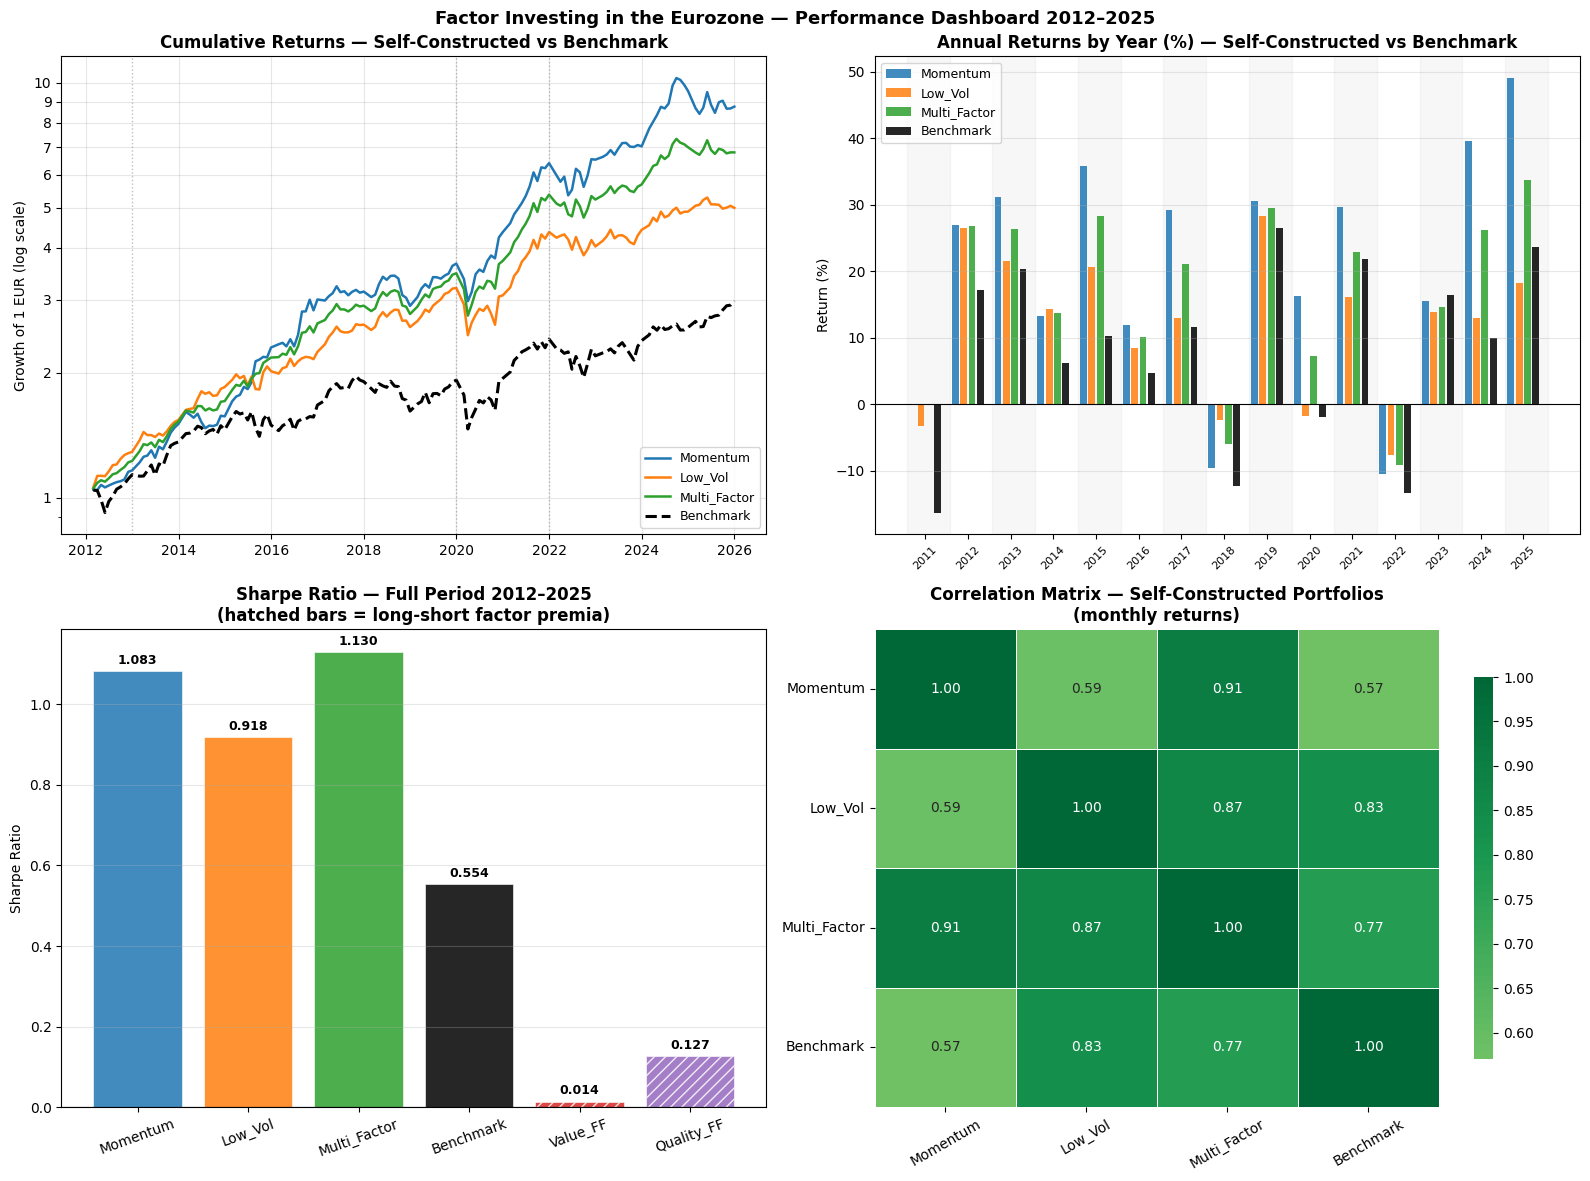

Saved: chapter5_charts.png


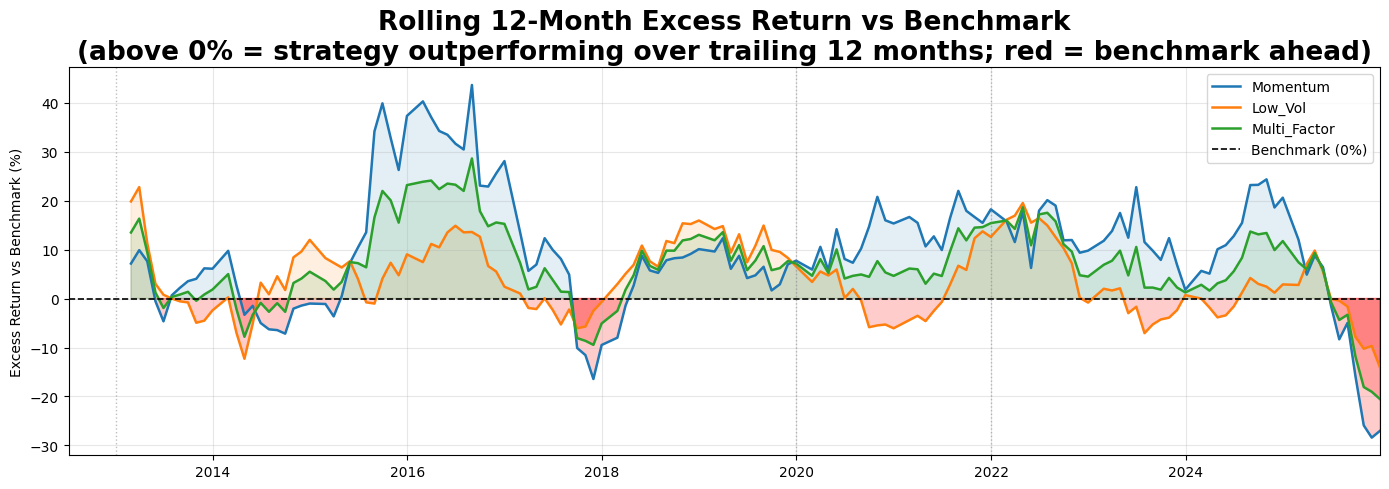

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

colors = {
    'Momentum': '#1f77b4', 'Low_Vol': '#ff7f0e',
    'Multi_Factor': '#2ca02c', 'Value_FF': '#d62728',
    'Quality_FF': '#9467bd', 'Benchmark': '#000000'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Factor Investing in the Eurozone — Performance Dashboard 2012–2025',
             fontsize=13, fontweight='bold')

# ── Chart 1: Cumulative returns (self-constructed only) ───
ax1 = axes[0, 0]

for col in ['Momentum', 'Low_Vol', 'Multi_Factor', 'Benchmark']:
    series = df_monthly[col].dropna()
    cum    = (1 + series).cumprod()
    ax1.plot(cum.index, cum.values, label=col, color=colors[col],
             linewidth=2.2 if col == 'Benchmark' else 1.8,
             linestyle='--' if col == 'Benchmark' else '-')

for yr in [2013, 2020, 2022]:
    ax1.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
                linestyle=':', alpha=0.5, linewidth=1)

ax1.set_title('Cumulative Returns — Self-Constructed vs Benchmark', fontweight='bold')
ax1.set_ylabel('Growth of 1 EUR (log scale)')
ax1.set_yscale('log')
ax1.set_yticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
ax1.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax1.get_yaxis().set_minor_formatter(mticker.NullFormatter())
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
# ── Chart 2: Annual returns (self-constructed only) ───────
ax2 = axes[0, 1]
plot_cols = ['Momentum', 'Low_Vol', 'Multi_Factor', 'Benchmark']
years = df_final.index.tolist()

w    = 0.18
gap  = 0.04
step = w + gap
group_width = step * len(plot_cols)

x = np.arange(len(years)) * (group_width + 0.25)  # 0.25 = space between years

for i, col in enumerate(plot_cols):
    vals = [df_final.loc[y, col] if (y in df_final.index and not pd.isna(df_final.loc[y, col])) else 0 for y in years]
    ax2.bar(x + i * step, vals, w, label=col, color=colors[col], alpha=0.85)

# alternating background bands per year
for j, xpos in enumerate(x):
    if j % 2 == 0:
        ax2.axvspan(xpos - 0.15, xpos + group_width + 0.1,
                    alpha=0.06, color='gray', zorder=0)

ax2.set_xticks(x + step * 1.5)
ax2.set_xticklabels(years, rotation=45, fontsize=8)
ax2.set_title('Annual Returns by Year (%) — Self-Constructed vs Benchmark',
              fontweight='bold')
ax2.set_ylabel('Return (%)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# ── Chart 3: Sharpe Ratio — all strategies, visual split
ax3 = axes[1, 0]
strategies  = ['Momentum', 'Low_Vol', 'Multi_Factor', 'Benchmark',
               'Value_FF', 'Quality_FF']
sharpes     = [df_metrics.loc[s, 'Sharpe Ratio'] for s in strategies]
bar_colors  = [colors[s] for s in strategies]
hatches     = ['', '', '', '', '///', '///']
bars = ax3.bar(strategies, sharpes, color=bar_colors, alpha=0.85,
               edgecolor='white', linewidth=0.5)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)
for bar, val in zip(bars, sharpes):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.06,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_title('Sharpe Ratio — Full Period 2012–2025\n(hatched bars = long-short factor premia)',
              fontweight='bold')
ax3.set_ylabel('Sharpe Ratio')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.tick_params(axis='x', rotation=20)
ax3.grid(True, alpha=0.3, axis='y')

# ── Chart 4: Correlation heatmap — self-constructed only
ax4 = axes[1, 1]
self_cols    = ['Momentum', 'Low_Vol', 'Multi_Factor', 'Benchmark']
df_corr_self = df_monthly[self_cols].corr().round(3)
sns.heatmap(df_corr_self, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax4, cbar_kws={'shrink': 0.8}, linewidths=0.5,
            annot_kws={'size': 10})
ax4.set_title('Correlation Matrix — Self-Constructed Portfolios\n(monthly returns)',
              fontweight='bold')
ax4.tick_params(axis='x', rotation=30)
ax4.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chapter5_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chapter5_charts.png")


# Rolling 12-Month Excess Return
fig2, ax = plt.subplots(figsize=(14, 5))

bm = df_monthly['Benchmark'][df_monthly.index < '2026-01-01']

for col in ['Momentum', 'Low_Vol', 'Multi_Factor']:
    strat       = df_monthly[col][df_monthly.index < '2026-01-01']
    excess      = strat - bm
    rolling_exc = excess.rolling(12).sum() * 100

    ax.plot(rolling_exc.index, rolling_exc.values,
            label=col, color=colors[col], linewidth=1.8)
    ax.fill_between(rolling_exc.index, rolling_exc.values, 0,
                    where=(rolling_exc.values >= 0),
                    alpha=0.12, color=colors[col], interpolate=True)
    ax.fill_between(rolling_exc.index, rolling_exc.values, 0,
                    where=(rolling_exc.values < 0),
                    alpha=0.20, color='red', interpolate=True)

ax.axhline(0, color='black', linewidth=1.2, linestyle='--', label='Benchmark (0%)')
for yr in [2013, 2020, 2022]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
               linestyle=':', alpha=0.5, linewidth=1)

ax.set_title('Rolling 12-Month Excess Return vs Benchmark\n'
             '(above 0% = strategy outperforming over trailing 12 months; red = benchmark ahead)',
             fontweight='bold', fontsize=19)

ax.set_ylabel('Excess Return vs Benchmark (%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(right=pd.Timestamp('2025-12-31'))
plt.tight_layout()
plt.savefig('rolling_excess_return.png', dpi=150, bbox_inches='tight')
plt.show()

Cell E - Final Excel export

In [36]:
with pd.ExcelWriter('chapter5_complete.xlsx', engine='openpyxl') as writer:

    # Performance summary — self-constructed
    df_metrics.loc[['Momentum','Low_Vol','Multi_Factor','Benchmark']].to_excel(
        writer, sheet_name='Perf_Self_Constructed')

    # Performance summary — factor premia
    df_metrics.loc[['Value_FF','Quality_FF']].to_excel(
        writer, sheet_name='Perf_Factor_Premia')

    # Annual returns
    df_final.to_excel(writer, sheet_name='Annual_Returns')

    # Monthly returns
    (df_monthly * 100).round(4).to_excel(writer, sheet_name='Monthly_Returns_Pct')

    # Descriptive stats — self-constructed
    df_desc_self.to_excel(writer, sheet_name='Desc_Stats_Self')

    # Descriptive stats — factor premia
    df_desc_premia.to_excel(writer, sheet_name='Desc_Stats_Premia')

    # Correlation matrices
    df_corr_self.to_excel(writer, sheet_name='Correlation_Self')
    df_corr.to_excel(writer,      sheet_name='Correlation_Full')

    # Subperiod — self-constructed
    for pname, df_p in subperiod_results.items():
        sheet = (pname[:27] + '_SC')
        df_p.loc[['Momentum','Low_Vol','Multi_Factor','Benchmark']].to_excel(
            writer, sheet_name=sheet)

    # Subperiod — factor premia
    for pname, df_p in subperiod_results.items():
        sheet = (pname[:27] + '_FP')
        df_p.loc[['Value_FF','Quality_FF']].to_excel(
            writer, sheet_name=sheet)

print("Saved: chapter5_complete.xlsx")
print("\nSheets:")
print("  Perf_Self_Constructed  → Sharpe, Sortino, MaxDD, Alpha for long-only")
print("  Perf_Factor_Premia     → same metrics for HML and RMW")
print("  Annual_Returns         → year by year all strategies")
print("  Monthly_Returns_Pct    → 154 months in %")
print("  Desc_Stats_Self        → descriptive stats long-only")
print("  Desc_Stats_Premia      → descriptive stats factor premia")
print("  Correlation_Self       → correlation matrix long-only")
print("  Correlation_Full       → full correlation matrix")
print("  4x _SC sheets          → subperiod self-constructed")
print("  4x _FP sheets          → subperiod factor premia")

Saved: chapter5_complete.xlsx

Sheets:
  Perf_Self_Constructed  → Sharpe, Sortino, MaxDD, Alpha for long-only
  Perf_Factor_Premia     → same metrics for HML and RMW
  Annual_Returns         → year by year all strategies
  Monthly_Returns_Pct    → 154 months in %
  Desc_Stats_Self        → descriptive stats long-only
  Desc_Stats_Premia      → descriptive stats factor premia
  Correlation_Self       → correlation matrix long-only
  Correlation_Full       → full correlation matrix
  4x _SC sheets          → subperiod self-constructed
  4x _FP sheets          → subperiod factor premia


Section 5.4


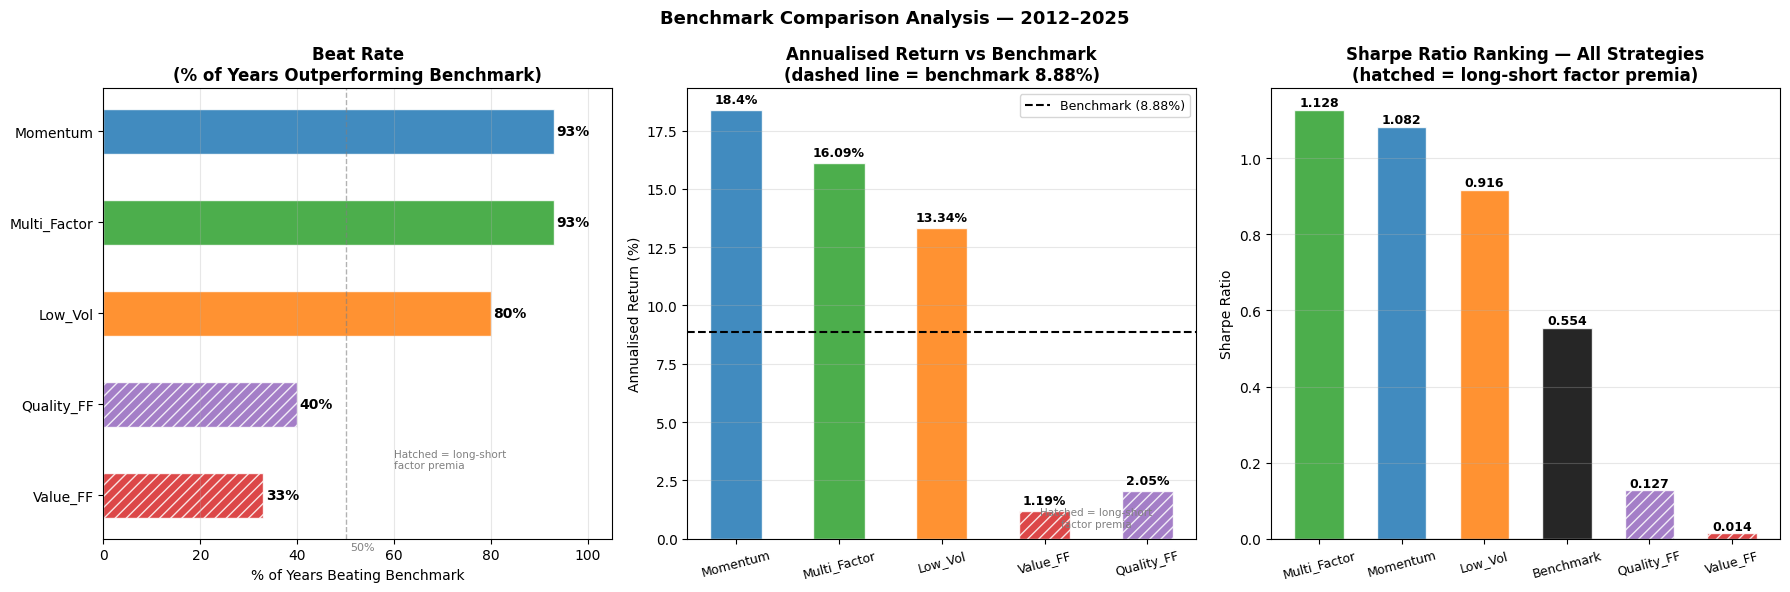

Saved: section54_charts_updated.png


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Benchmark Comparison Analysis — 2012–2025',
             fontsize=13, fontweight='bold')

# ── Chart 1: Beat Rate horizontal bar ────────────────────
ax1 = axes[0]
strategies1  = ['Value_FF', 'Quality_FF', 'Low_Vol', 'Multi_Factor', 'Momentum']
beat_rates1  = [33, 40, 80, 93, 93]
bar_colors1  = ['#d62728', '#9467bd', '#ff7f0e', '#2ca02c', '#1f77b4']
hatches1     = ['///', '///', '', '', '']

bars1 = ax1.barh(strategies1, beat_rates1, color=bar_colors1,
                 alpha=0.85, edgecolor='white', height=0.5)
for bar, hatch in zip(bars1, hatches1):
    bar.set_hatch(hatch)
for bar, val in zip(bars1, beat_rates1):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val}%', va='center', fontsize=10, fontweight='bold')

ax1.axvline(50, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax1.text(51, -0.6, '50%', color='gray', fontsize=8)
ax1.set_xlabel('% of Years Beating Benchmark')
ax1.set_title('Beat Rate\n(% of Years Outperforming Benchmark)',
              fontweight='bold')
ax1.set_xlim(0, 105)
ax1.grid(True, alpha=0.3, axis='x')
ax1.text(60, 0.3, 'Hatched = long-short\nfactor premia',
         fontsize=7.5, color='gray')

# ── Chart 2: Annualised returns vs benchmark ──────────────
ax2 = axes[1]
strategies2  = ['Momentum', 'Multi_Factor', 'Low_Vol', 'Value_FF', 'Quality_FF']
ann_returns  = [18.40, 16.09, 13.34, 1.19, 2.05]
bar_colors2  = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
hatches2     = ['', '', '', '///', '///']
x = np.arange(len(strategies2))

bars2 = ax2.bar(x, ann_returns, color=bar_colors2, alpha=0.85,
                edgecolor='white', width=0.5)
for bar, hatch in zip(bars2, hatches2):
    bar.set_hatch(hatch)
for bar, val in zip(bars2, ann_returns):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=9, fontweight='bold')

ax2.axhline(8.88, color='black', linestyle='--',
            linewidth=1.5, label='Benchmark (8.88%)')
ax2.set_xticks(x)
ax2.set_xticklabels(strategies2, rotation=15, fontsize=9)
ax2.set_ylabel('Annualised Return (%)')
ax2.set_title('Annualised Return vs Benchmark\n(dashed line = benchmark 8.88%)',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.text(3.5, 0.5, 'Hatched = long-short\nfactor premia',
         fontsize=7.5, color='gray', ha='center')

# ── Chart 3: Sharpe Ratio ranking ────────────────────────
ax3 = axes[2]
strategies3 = ['Momentum', 'Multi_Factor', 'Low_Vol', 'Benchmark',
                'Quality_FF', 'Value_FF']
sharpes3    = [1.082, 1.128, 0.916, 0.554, 0.127, 0.014]
bar_colors3 = ['#1f77b4', '#2ca02c', '#ff7f0e', '#000000',
               '#9467bd', '#d62728']
hatches3    = ['', '', '', '', '///', '///']

sorted_data = sorted(zip(sharpes3, strategies3, bar_colors3, hatches3),
                     reverse=True)
sharpes3_s, strategies3_s, colors3_s, hatches3_s = zip(*sorted_data)

bars3 = ax3.bar(range(len(strategies3_s)), sharpes3_s,
                color=list(colors3_s), alpha=0.85,
                edgecolor='white', width=0.6)
for bar, hatch in zip(bars3, hatches3_s):
    bar.set_hatch(hatch)
for bar, val in zip(bars3, sharpes3_s):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax3.set_xticks(range(len(strategies3_s)))
ax3.set_xticklabels(list(strategies3_s), rotation=15, fontsize=9)
ax3.set_ylabel('Sharpe Ratio')
ax3.set_title('Sharpe Ratio Ranking — All Strategies\n(hatched = long-short factor premia)',
              fontweight='bold')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('section54_charts_updated.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: section54_charts_updated.png")

Section 5.5

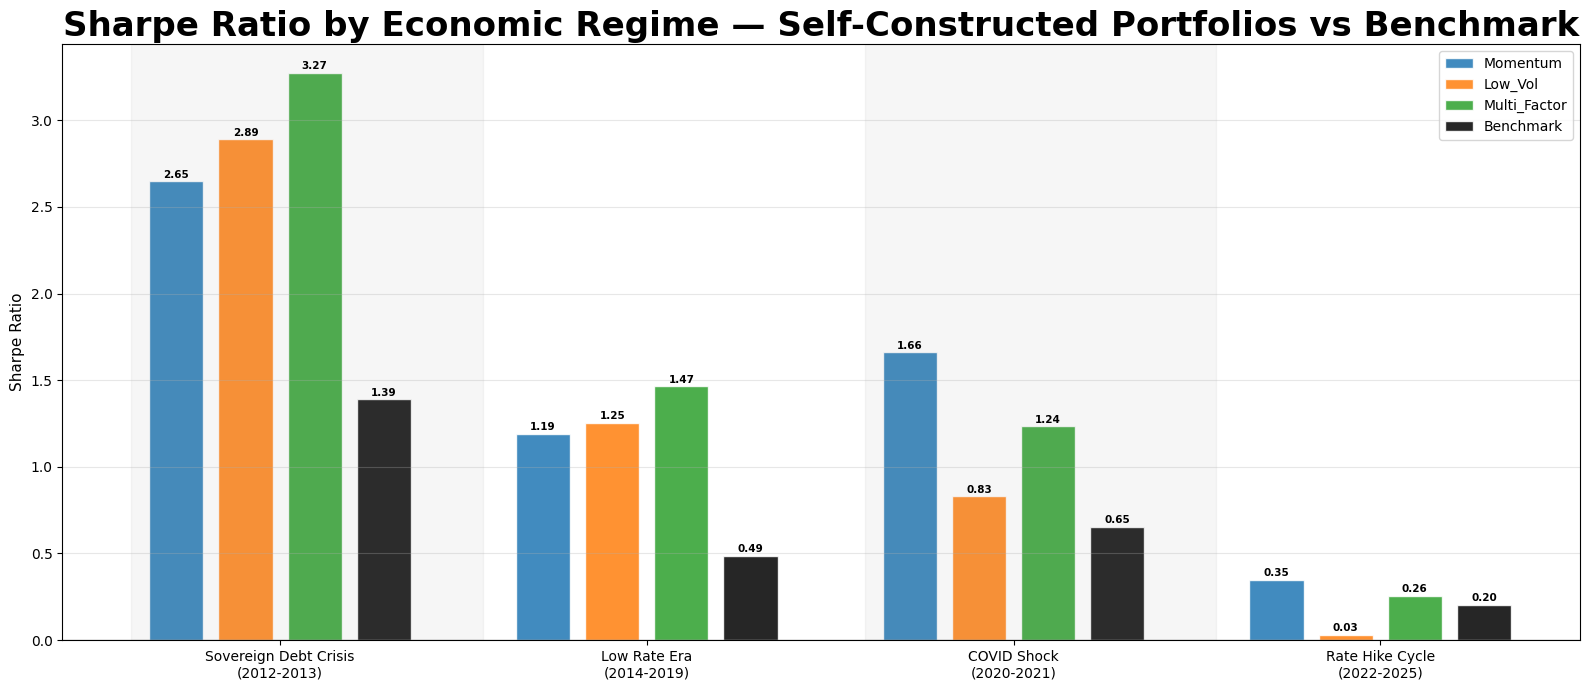

Saved: section55_regime_chart.png


In [38]:
fig, ax = plt.subplots(figsize=(16, 7))

regimes = list(subperiod_results.keys())
strategies_plot = ['Momentum', 'Low_Vol', 'Multi_Factor', 'Benchmark']

colors = {
    'Momentum':     '#1f77b4',
    'Low_Vol':      '#ff7f0e',
    'Multi_Factor': '#2ca02c',
    'Benchmark':    '#000000',
}

w = 0.18
gap = 0.05
step = w + gap
group_width = step * len(strategies_plot)

x = np.arange(len(regimes)) * (group_width + 0.3)  # 0.3 = space between regimes

for i, strategy in enumerate(strategies_plot):
    values = [subperiod_results[regime].loc[strategy, 'Sharpe Ratio']
              for regime in regimes]
    bars = ax.bar(x + i * step, values, w, label=strategy,
                  color=colors[strategy], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.12,
                f'{val:.2f}', ha='center', fontsize=7.5, fontweight='bold')

regime_labels = [r.split('(')[0].strip() + '\n(' + r.split('(')[1]
                 if '(' in r else r for r in regimes]
ax.set_xticks(x + step * 1.5)
ax.set_xticklabels(regime_labels, fontsize=10)
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Sharpe Ratio by Economic Regime — Self-Constructed Portfolios vs Benchmark',
             fontsize=24.5, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for j in [0, 2]:
    ax.axvspan(x[j] - 0.15, x[j] + group_width + 0.1, alpha=0.07, color='gray')

plt.tight_layout()
plt.savefig('section55_regime_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: section55_regime_chart.png")

Dynamic Max DrawDown table

In [39]:
# Dynamically extract Max Drawdown by regime from subperiod_results
strategies_table = ['Momentum', 'Low_Vol', 'Multi_Factor', 'Benchmark']
regimes_short    = {
    'Sovereign Debt Crisis (2012-2013)': '2012-2013',
    'Low Rate Era (2014-2019)':          '2014-2019',
    'COVID Shock (2020-2021)':           '2020-2021',
    'Rate Hike Cycle (2022-2025)':       '2022-2025',
}

rows = {}
for strategy in strategies_table:
    rows[strategy] = {
        short: f"{subperiod_results[full].loc[strategy, 'Max Drawdown (%)']:.2f}%"
        for full, short in regimes_short.items()
    }

df_maxdd = pd.DataFrame(rows).T
df_maxdd.index.name = 'Strategy'

print("MAX DRAWDOWN BY REGIME (%)")
print("=" * 65)
print(df_maxdd.to_string())

df_maxdd.to_csv('maxdrawdown_by_regime.csv')
print("\nSaved: maxdrawdown_by_regime.csv")

MAX DRAWDOWN BY REGIME (%)
             2012-2013 2014-2019 2020-2021 2022-2025
Strategy                                            
Momentum        -4.08%   -15.45%   -11.55%   -18.01%
Low_Vol         -2.75%    -9.21%   -15.66%   -10.95%
Multi_Factor    -2.58%   -12.37%   -13.60%    -9.58%
Benchmark      -11.62%   -17.56%   -17.19%   -14.76%

Saved: maxdrawdown_by_regime.csv


Section 5.6

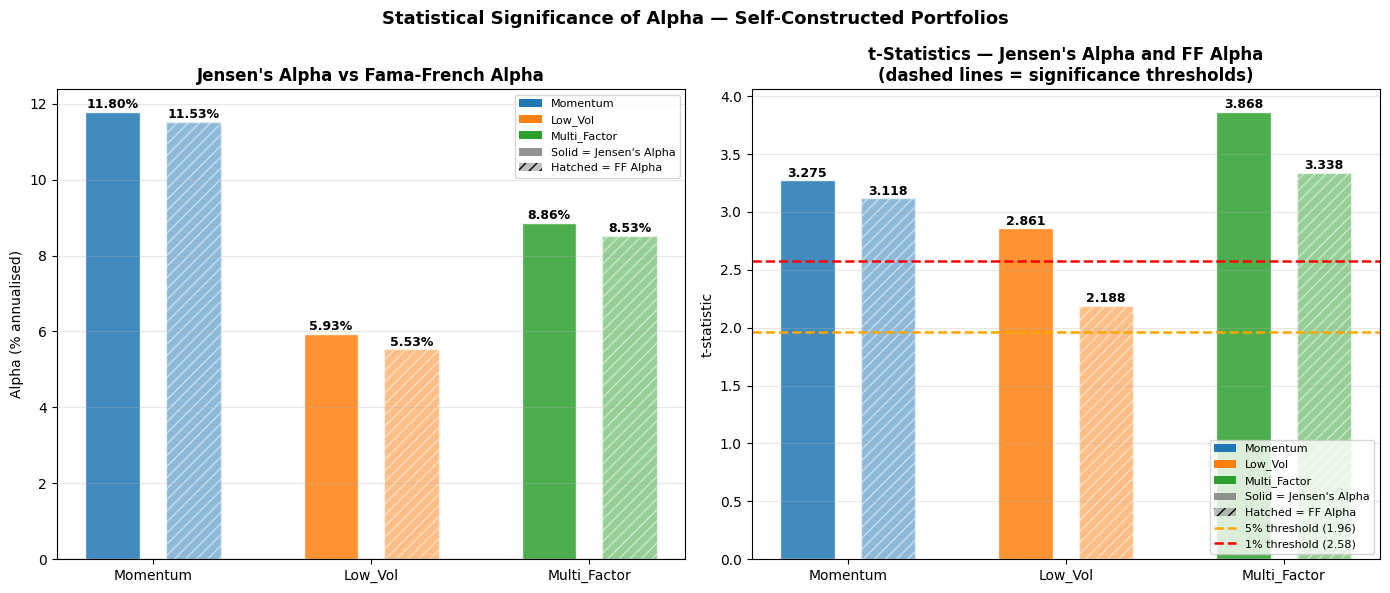

Saved: section56_significance_charts.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Statistical Significance of Alpha — Self-Constructed Portfolios',
             fontsize=13, fontweight='bold')

strategies = ['Momentum', 'Low_Vol', 'Multi_Factor']
colors     = ['#1f77b4', '#ff7f0e', '#2ca02c']

j_alphas  = [df_summary.loc[s, 'Jensens_Alpha (%)'] for s in strategies]
ff_alphas = [df_summary.loc[s, 'FF_Alpha (%)']      for s in strategies]
j_tstats  = [3.275, 2.861, 3.868]
ff_tstats = [3.118, 2.188, 3.338]

w   = 0.25
gap = 0.12
x   = np.arange(len(strategies))

# ── Chart 1: Alpha comparison ─────────────────────────────
ax1 = axes[0]

for i, (strategy, color) in enumerate(zip(strategies, colors)):
    ax1.bar(x[i] - (w/2 + gap/2), j_alphas[i],  w, color=color,
            alpha=0.85, edgecolor='white')
    ax1.bar(x[i] + (w/2 + gap/2), ff_alphas[i], w, color=color,
            alpha=0.50, edgecolor='white', hatch='///')
    ax1.text(x[i] - (w/2 + gap/2), j_alphas[i]  + 0.1,
             f'{j_alphas[i]:.2f}%',  ha='center', fontsize=9, fontweight='bold')
    ax1.text(x[i] + (w/2 + gap/2), ff_alphas[i] + 0.1,
             f'{ff_alphas[i]:.2f}%', ha='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
strategy_legend = [Patch(facecolor=c, label=s)
                   for s, c in zip(strategies, colors)]
type_legend = [
    Patch(facecolor='gray', alpha=0.85, label="Solid = Jensen's Alpha"),
    Patch(facecolor='gray', alpha=0.50, hatch='///', label='Hatched = FF Alpha'),
]
ax1.legend(handles=strategy_legend + type_legend, fontsize=8, loc='upper right')
ax1.set_xticks(x)
ax1.set_xticklabels(strategies, fontsize=10)
ax1.set_ylabel('Alpha (% annualised)', fontsize=10)
ax1.set_title("Jensen's Alpha vs Fama-French Alpha", fontweight='bold')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.grid(True, alpha=0.3, axis='y')

# ── Chart 2: t-statistics ─────────────────────────────────
ax2 = axes[1]

for i, (strategy, color) in enumerate(zip(strategies, colors)):
    ax2.bar(x[i] - (w/2 + gap/2), j_tstats[i],  w, color=color,
            alpha=0.85, edgecolor='white')
    ax2.bar(x[i] + (w/2 + gap/2), ff_tstats[i], w, color=color,
            alpha=0.50, edgecolor='white', hatch='///')
    ax2.text(x[i] - (w/2 + gap/2), j_tstats[i]  + 0.03,
             f'{j_tstats[i]:.3f}',  ha='center', fontsize=9, fontweight='bold')
    ax2.text(x[i] + (w/2 + gap/2), ff_tstats[i] + 0.03,
             f'{ff_tstats[i]:.3f}', ha='center', fontsize=9, fontweight='bold')

ax2.axhline(1.960, color='orange', linestyle='--',
            linewidth=1.8, label='5% threshold (1.96)')
ax2.axhline(2.576, color='red',    linestyle='--',
            linewidth=1.8, label='1% threshold (2.58)')

threshold_legend = [
    plt.Line2D([0], [0], color='orange', linestyle='--',
               linewidth=1.8, label='5% threshold (1.96)'),
    plt.Line2D([0], [0], color='red',    linestyle='--',
               linewidth=1.8, label='1% threshold (2.58)'),
]
ax2.legend(handles=strategy_legend + type_legend + threshold_legend,
           fontsize=8, loc='lower right',
           bbox_to_anchor=(1.0, 0.0))
ax2.set_xticks(x)
ax2.set_xticklabels(strategies, fontsize=10)
ax2.set_ylabel('t-statistic', fontsize=10)
ax2.set_title("t-Statistics — Jensen's Alpha and FF Alpha\n"
              "(dashed lines = significance thresholds)",
              fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('section56_significance_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: section56_significance_charts.png")

Appendices Code

In [42]:
# ============================================================
# APPENDIX TABLES — Run this after all other cells
# ============================================================

import pandas as pd
import numpy as np

# ── Load base data ───────────────────────────────────────────
universe  = pd.read_csv('universe.csv')
prices    = pd.read_csv('stock_prices.csv', index_col=0, parse_dates=True)

# Identify which tickers made it through the 30% missing data filter
final_tickers = set(prices.columns)

# Build ticker → metadata lookup from universe
ticker_to_name    = dict(zip(universe['yf_ticker'], universe['Name']))
ticker_to_country = dict(zip(universe['yf_ticker'], universe['Location']))
ticker_to_sector  = dict(zip(universe['yf_ticker'], universe['Sector']))
ticker_to_issuer  = dict(zip(universe['yf_ticker'], universe['Issuer Ticker']))


# ============================================================
# APPENDIX A — Investment Universe (190 Stocks)
# ============================================================

appendix_a = universe[universe['yf_ticker'].isin(final_tickers)].copy()

appendix_a = appendix_a.rename(columns={
    'Issuer Ticker': 'Ticker',
    'Name':          'Company Name',
    'Location':      'Country',
    'Sector':        'Sector',
})

appendix_a = appendix_a[['Ticker', 'Company Name', 'Sector', 'Country']]
appendix_a = appendix_a.sort_values(['Country', 'Company Name']).reset_index(drop=True)
appendix_a.insert(0, 'No.', range(1, len(appendix_a) + 1))

print("=" * 70)
print(f"APPENDIX A — Investment Universe ({len(appendix_a)} Stocks)")
print("=" * 70)
print(appendix_a.to_string(index=False))
appendix_a.to_csv('appendix_a_universe.csv', index=False)
print(f"\nSaved: appendix_a_universe.csv")


# ============================================================
# Capture all 34 excluded stocks including unmapped ones ──────

# Reload original holdings
df_holdings_raw = pd.read_csv('iShare_Holdings_only.csv', skiprows=7, on_bad_lines='skip')
df_holdings_raw = df_holdings_raw.dropna(how='all')
df_holdings_raw = df_holdings_raw[df_holdings_raw['Asset Class'] == 'Equity'].copy()

# Apply same ticker mapping as before
df_holdings_raw['yf_ticker'] = df_holdings_raw.apply(to_yf_ticker, axis=1)

# GROUP 1: stocks excluded because exchange was not in exchange_map
unmapped = df_holdings_raw[df_holdings_raw['yf_ticker'].isna()].copy()
unmapped['Exclusion Reason'] = 'Exchange not mapped / not Eurozone-listed'

# GROUP 2: stocks that were mapped but dropped due to >30% missing data
# These are in universe.csv but not in final prices
universe  = pd.read_csv('universe.csv')
prices    = pd.read_csv('stock_prices.csv', index_col=0, parse_dates=True)
final_tickers = set(prices.columns)

missing_data = universe[~universe['yf_ticker'].isin(final_tickers)].copy()
missing_data['Exclusion Reason'] = '>30% missing price data over 2010–2025'

# Build unified Appendix B
group1 = unmapped[['Issuer Ticker', 'Name', 'Location',
                    'Exchange', 'Exclusion Reason']].rename(columns={
    'Issuer Ticker': 'Ticker',
    'Name':          'Company Name',
    'Location':      'Country',
    'Exchange':      'Exchange',
})

group2 = missing_data[['Issuer Ticker', 'Name', 'Location',
                        'Exclusion Reason']].rename(columns={
    'Issuer Ticker': 'Ticker',
    'Name':          'Company Name',
    'Location':      'Country',
})
group2['Exchange'] = 'Mapped — insufficient data'

appendix_b_full = pd.concat([group1, group2], ignore_index=True)
appendix_b_full = appendix_b_full.sort_values(
    ['Country', 'Company Name']).reset_index(drop=True)
appendix_b_full.insert(0, 'No.', range(1, len(appendix_b_full) + 1))

print(f"Total excluded stocks: {len(appendix_b_full)}")
print(f"  — Unmapped exchange:     {len(group1)}")
print(f"  — Missing price data:    {len(group2)}")
print()
print(appendix_b_full[['No.', 'Ticker', 'Company Name',
                        'Country', 'Exclusion Reason']].to_string(index=False))

appendix_b_full.to_csv('appendix_b_excluded_full.csv', index=False)
print("\nSaved: appendix_b_excluded_full.csv")
# ============================================================
# APPENDIX C — Annual Portfolio Compositions
# Momentum and Low Volatility, holding year by year
# ============================================================

momentum_df = pd.read_csv('momentum_portfolios.csv')
lowvol_df   = pd.read_csv('lowvol_portfolios.csv')

# Columns are formation years (2011, 2012 ... 2024)
# Holding year = formation year + 1 (2012 ... 2025)

def build_composition_table(portfolio_df, portfolio_name):
    rows = []
    for col in portfolio_df.columns:
        formation_year = int(col)
        holding_year   = formation_year + 1
        tickers = portfolio_df[col].dropna().tolist()

        for ticker in tickers:
            rows.append({
                'Holding Year': holding_year,
                'Ticker':       ticker_to_issuer.get(ticker, ticker),
                'yf_ticker':    ticker,
                'Company Name': ticker_to_name.get(ticker, ticker),
                'Country':      ticker_to_country.get(ticker, 'N/A'),
                'Sector':       ticker_to_sector.get(ticker, 'N/A'),
            })

    df = pd.DataFrame(rows).sort_values(
        ['Holding Year', 'Country', 'Company Name']
    ).reset_index(drop=True)

    print(f"\n{'=' * 70}")
    print(f"APPENDIX C — {portfolio_name} Portfolio Annual Compositions")
    print(f"{'=' * 70}")
    for year in sorted(df['Holding Year'].unique()):
        sub = df[df['Holding Year'] == year]
        print(f"\n  {year} — {len(sub)} stocks selected")
        print(sub[['Ticker', 'Company Name', 'Country',
                   'Sector']].to_string(index=False))

    return df

momentum_comp = build_composition_table(momentum_df, 'Momentum')
lowvol_comp   = build_composition_table(lowvol_df,   'Low Volatility')

momentum_comp.to_csv('appendix_c_momentum_compositions.csv', index=False)
lowvol_comp.to_csv('appendix_c_lowvol_compositions.csv',     index=False)

print("\nSaved:")
print("  appendix_c_momentum_compositions.csv")
print("  appendix_c_lowvol_compositions.csv")


# ============================================================
# SUMMARY COUNTS
# ============================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"  Appendix A — Universe:            {len(appendix_a)} stocks")
print(f"  Appendix B — Excluded:            {len(appendix_b)} stocks")
print(f"  Appendix A + B total:             "
      f"{len(appendix_a) + len(appendix_b)} stocks")
print(f"  Appendix C — Momentum entries:    {len(momentum_comp)} "
      f"(~{len(momentum_comp)//14} stocks × 14 years)")
print(f"  Appendix C — Low Vol entries:     {len(lowvol_comp)} "
      f"(~{len(lowvol_comp)//14} stocks × 14 years)")

APPENDIX A — Investment Universe (190 Stocks)
 No. Ticker                       Company Name                 Sector     Country
   1    EBS                ERSTE GROUP BANK AG             Financials     Austria
   2    OMV                             OMV AG                 Energy     Austria
   3    RBI   RAIFFEISEN BANK INTERNATIONAL AG             Financials     Austria
   4    VER                         VERBUND AG              Utilities     Austria
   5    AGS                           AGEAS SA             Financials     Belgium
   6    ABI            ANHEUSER-BUSCH INBEV SA       Consumer Staples     Belgium
   7   ARGX                             ARGENX            Health Care     Belgium
   8    DIE                    DIETEREN (D) SA Consumer Discretionary     Belgium
   9    ELI                      ELIA GROUP SA              Utilities     Belgium
  10    TUB            FINANCIERE DE TUBIZE SA            Health Care     Belgium
  11   GBLB        GROUPE BRUXELLES LAMBERT NV      

In [45]:
print(df_holdings_raw[df_holdings_raw['yf_ticker'].isna()][
    ['Issuer Ticker', 'Name', 'Location', 'Exchange']])

   Issuer Ticker                                Name     Location  \
61          NBIS                   NEBIUS NV CLASS A  Netherlands   
79           AER                  AERCAP HOLDINGS NV  Netherlands   
97          CCEP  COCA COLA EUROPACIFIC PARTNERS PLC  Netherlands   

                        Exchange  
61                        NASDAQ  
79  New York Stock Exchange Inc.  
97                        NASDAQ  
